48000
1248000
Downsampling data by a factor of 1000...
(312, 1248000)
Downsampled array shape: (312, 1248)
Creating heatmap...


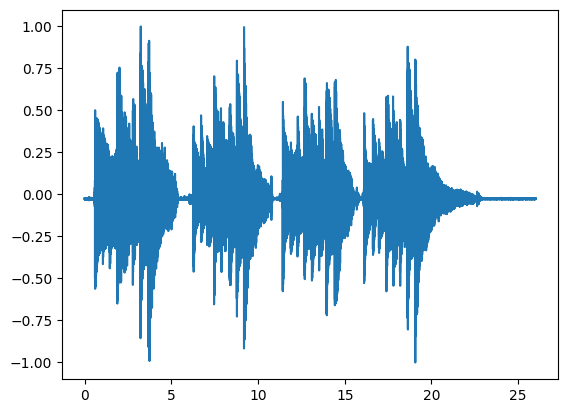

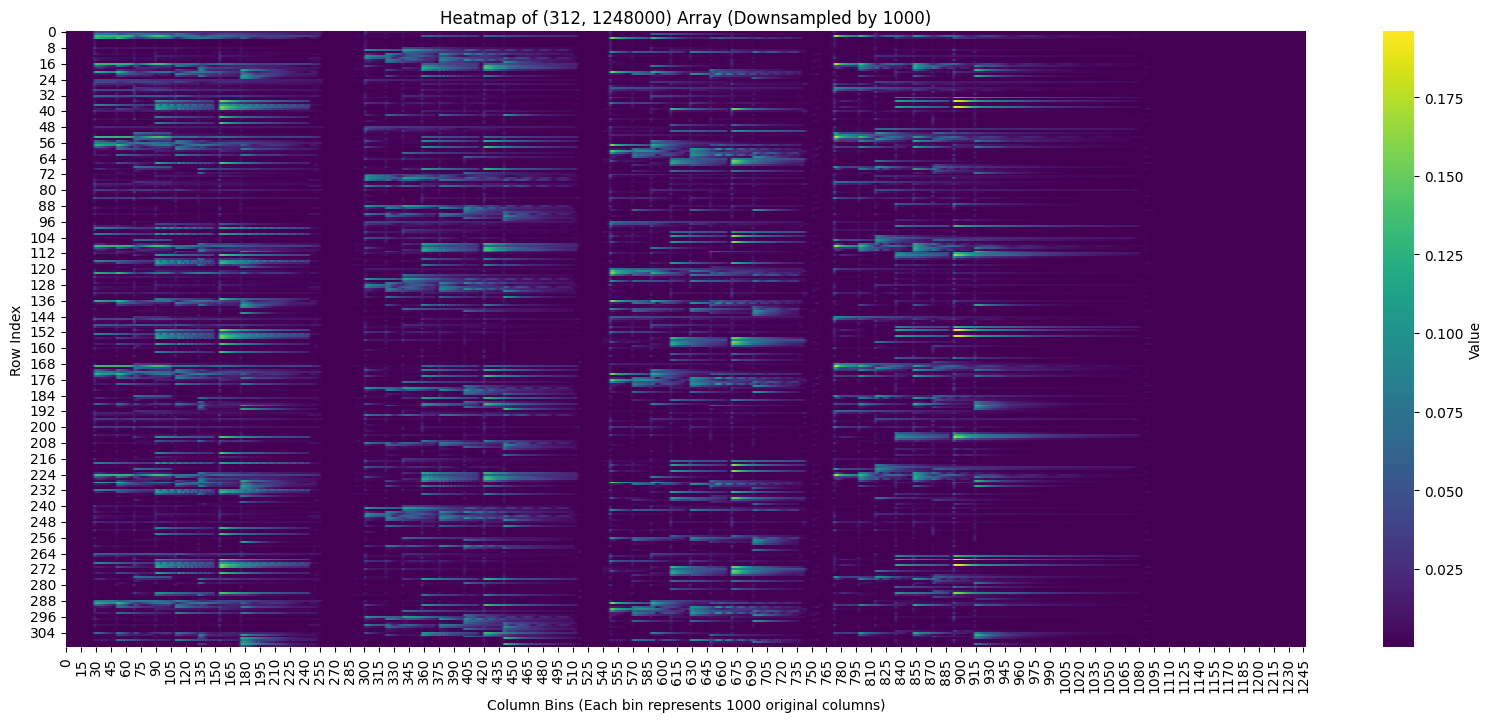

Heatmap displayed.
reshape data by a factor of 256...
(312, 1248000)
Reshaped the output data to  
(4875, 312)
Downsampling data by a factor of 1...
(312, 4875)
Downsampled array shape: (312, 4875)
Creating heatmap...


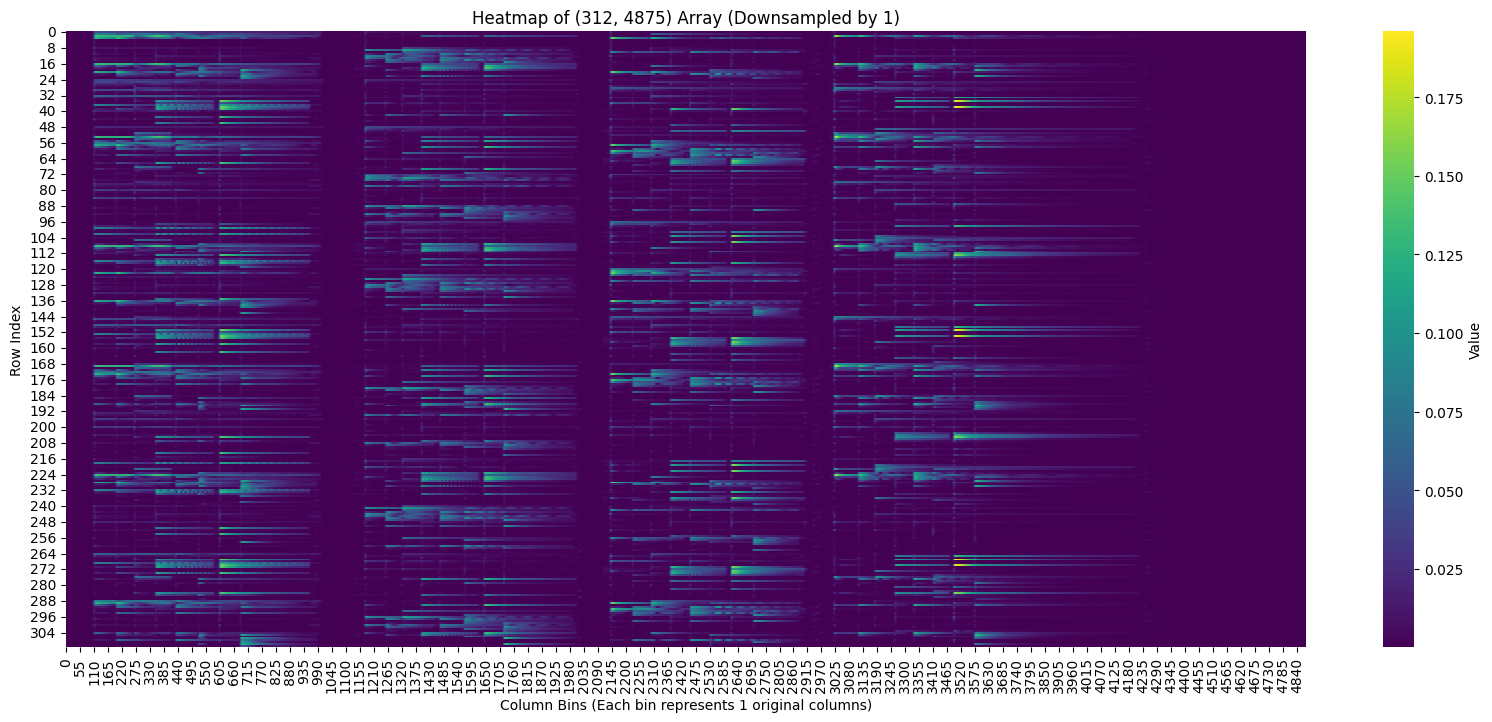

Heatmap displayed.


In [1]:
from scipy import io
from fretboard import FretBoard
import numpy
import matplotlib.pyplot as plt
import wave
from common import plot_heatmap,reshape_to_nn_input
sampleRate,input_signal_test=io.wavfile.read('../../assets/testdata/E-G-A-B-chords.wav')
# sampleRate,input_signal_test=io.wavfile.read('../../assets/trainingdata/chords/session_original.wav')
print(sampleRate)
filter=FretBoard(20,sampleRate)
numfilters=filter.get_num_filters()
audio_test=input_signal_test#[:,1];

audiomin=numpy.min(audio_test)
audiomax=numpy.max(audio_test)

audio_test=numpy.multiply((audio_test-audiomin)/(audiomax-audiomin),2)-1
print(len(audio_test))
nFrames =input_signal_test.shape[0]
time=numpy.linspace(0,len(audio_test)/sampleRate,len(audio_test))

plt.plot(time, audio_test, label='Input')

filterbank_out_test=numpy.zeros((numfilters,len(audio_test)))

filter.process(audio_test,filterbank_out_test)

plot_heatmap(filterbank_out_test)

nn_input_test=reshape_to_nn_input(filterbank_out_test)

plot_heatmap(nn_input_test.swapaxes(0,1),downsample_factor=1)

2025-10-26 22:05:26.784939: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-26 22:05:26.790606: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-26 22:05:26.796494: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-26 22:05:26.798358: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-26 22:05:26.803593: I tensorflow/core/platform/cpu_feature_guar

(4875, 312)
(312, 1)


I0000 00:00:1761516327.592182  166178 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1761516327.614990  166178 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1761516327.616126  166178 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1761516327.618893  166178 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

dummy shape(4875, 312)
(1, 312)
(1, 312, 1)
(312,)


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
2025-10-26 22:05:28.094009: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90701
W0000 00:00:1761516328.120528  166382 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1761516328.126650  166382 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1761516328.132987  166382 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1761516328.133167  166382 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1761516328.133349  166382 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1761516328.133532  166382 gpu_timer.cc:114] Skipping t

predictions shape(89, 1)
(89, 256)
89
(89, 1)


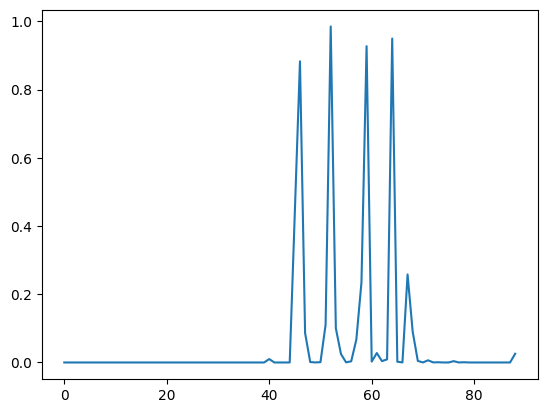

In [2]:
from common import INPUT_SHAPE,OUTPUT_DIM_NOTES,OUTPUT_DIM_ONSETS
import numpy as np
from model import build_cnn_model
print(nn_input_test.shape)
print(INPUT_SHAPE)
cnn_model=build_cnn_model(INPUT_SHAPE,OUTPUT_DIM_NOTES)
cnn_model.load_weights('guitarmidi.weights.h5')

dummy_filter_outputs_2d = nn_input_test.reshape(nn_input_test.shape[0],nn_input_test.shape[1])#,nn_input_test.shape[2])#np.random.rand(256, 288).astype(np.float32)

print('dummy shape'+str(dummy_filter_outputs_2d.shape))

# Reshape for the model: (batch_size, time_steps, num_filters, channels)
# For single inference, batch_size = 1, channels = 1
outsample=115
input_for_model = np.expand_dims(dummy_filter_outputs_2d[int(outsample)], axis=0)  # Add batch dimension

print(input_for_model.shape)
input_for_model = np.expand_dims(input_for_model, axis=-1) # Add channel dimension

print(input_for_model.shape)

print(nn_input_test[int(outsample)].shape)
predictions_cnn = cnn_model.predict(input_for_model, verbose=0)

predictions_cnn=np.swapaxes(predictions_cnn,0,1)
print('predictions shape'+str(predictions_cnn.shape))
pred=np.repeat(predictions_cnn,256,axis=1)
print(pred.shape)
#plot_heatmap(pred)

# print(predictions_cnn)
xpred=range(1,len(predictions_cnn))
print(len(predictions_cnn))
print(predictions_cnn.shape)
plt.plot(predictions_cnn)
plt.show()

# plt.plot(nn_output[int(outsample/256)])

In [3]:
import numpy as np

# Let's say your original matrix is:
A = np.random.rand(4000, 89)  # just as an example matrix

# Repeat each row 256 times
A_expanded = np.repeat(A, 256, axis=0)  # shape will be (4000*256, 89)

print(A_expanded.shape)  # Output: (1024000, 89)


(1024000, 89)
